# CIFAR-10 — Simple ResNet

A lightweight ResNet with one `SimpleResBlock` per stage (4 stages).
This introduces residual connections to the baseline CNN to demonstrate
their impact on gradient flow and convergence.

## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar10_dataloaders, CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [3]:
batch_size = 256

trainloader, valloader, testloader = get_cifar10_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=32,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 157 | Val batches: 40 | Test batches: 40


## Visualize Sample Batch

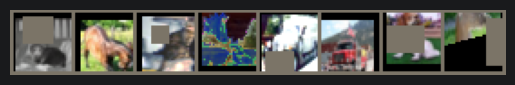

cat   horse cat   deer  truck truck dog   deer 


In [4]:
show_sample_batch(trainloader, CLASSES)

## Model Definition

### SimpleResBlock
A basic residual block: two 3×3 convolutions with BatchNorm and a
1×1 shortcut projection when dimensions change.

### SimpleResNet
Initial conv → 4 residual stages → Global Average Pooling → FC.

In [5]:
class SimpleResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SimpleResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class SimpleResNet(nn.Module):
    def __init__(self):
        super(SimpleResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = SimpleResBlock(64, 64, stride=1)
        self.layer2 = SimpleResBlock(64, 128, stride=2)
        self.layer3 = SimpleResBlock(128, 256, stride=2)
        self.layer4 = SimpleResBlock(256, 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Initialize Model & Print Summary

In [6]:
model = SimpleResNet().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): SimpleResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
  )
  (layer2): SimpleResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running

## Training Configuration

In [7]:
criterion = nn.CrossEntropyLoss()
epochs = 80
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

scaler = torch.amp.GradScaler('cuda')

checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path='../../checkpoint/simple_resnet_latest.pth',
    best_model_path='../../checkpoint/simple_resnet_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [8]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
)

[ModelCheckpoint] New best (max): 44.5000 — saved to ..\checkpoint\simple_resnet_best.pth
Epoch [ 1/80]  Train Loss: 1.9582  Val Loss: 1.5099  Val Acc: 44.50%  LR: 0.004411  Time: 16.76s
[ModelCheckpoint] New best (max): 51.3600 — saved to ..\checkpoint\simple_resnet_best.pth
Epoch [ 2/80]  Train Loss: 1.6509  Val Loss: 1.4163  Val Acc: 51.36%  LR: 0.005636  Time: 4.26s
[ModelCheckpoint] New best (max): 56.1400 — saved to ..\checkpoint\simple_resnet_best.pth
Epoch [ 3/80]  Train Loss: 1.4870  Val Loss: 1.2408  Val Acc: 56.14%  LR: 0.007656  Time: 4.19s
Epoch [ 4/80]  Train Loss: 1.3715  Val Loss: 1.6107  Val Acc: 49.70%  LR: 0.010434  Time: 4.32s
[ModelCheckpoint] New best (max): 56.2600 — saved to ..\checkpoint\simple_resnet_best.pth
Epoch [ 5/80]  Train Loss: 1.2866  Val Loss: 1.4115  Val Acc: 56.26%  LR: 0.013924  Time: 4.16s
[ModelCheckpoint] New best (max): 62.0400 — saved to ..\checkpoint\simple_resnet_best.pth
Epoch [ 6/80]  Train Loss: 1.2101  Val Loss: 1.1200  Val Acc: 62.04% 

## Restore Best Weights & Test Evaluation

In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\simple_resnet_best.pth (score=93.8000)

Overall Test Accuracy: 93.77%

  plane: 94.8%
  car  : 97.7%
  bird : 90.8%
  cat  : 83.9%
  deer : 95.9%
  dog  : 89.4%
  frog : 96.8%
  horse: 96.0%
  ship : 96.5%
  truck: 95.9%


## Training Curves

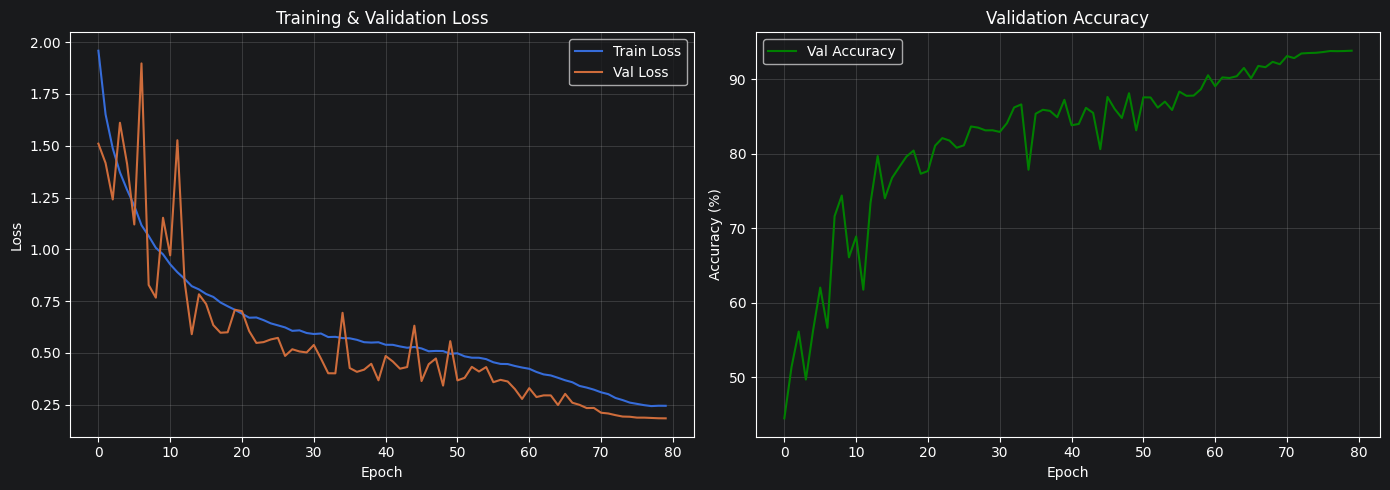

In [10]:
plot_training_curves(train_losses, val_losses, val_accuracies)